# Setup Environment
We need to clone the repository and install dependencies to use the `src` module in Colab.

In [ ]:
import os
repo_url = 'https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning.git'
repo_name = 'Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning'

if not os.path.exists(repo_name):
    !git clone {repo_url}

%cd /content/{repo_name}

# Completely purge existing torch/numpy and hidden cache files
!pip uninstall -y torch torchvision torchaudio numpy
!rm -rf /usr/local/lib/python3.12/dist-packages/~*

# Perform a fresh installation of compatible versions
!pip install "numpy<2.0" "torch>=2.4.0" "transformers>=4.44.0" "transformer_lens" --quiet

print("\nEnvironment cleaned and reinstalled. You MUST now go to Runtime -> Restart session.")

## Go to top menu: Runtime -> Restart session of collab, and only after that run the cells below


## Initialization and Imports

In [1]:
import sys
import os
from pathlib import Path

# Set absolute path to repo root
repo_root = "/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.induction_score import compute_induction_score_with_stats, identify_induction_heads
from src.viz.attention_vis import plot_induction_score_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print("Modules imported successfully from src.")

Device: cuda
Modules imported successfully from src.


# Notebook 01: Baseline Replication

**Goal:** Replicate the induction circuit in the pretrained `attn-only-2l` model.

**Outputs:** `experiments/results/baseline_induction_scores.npz`, `paper/figures/fig3_*`

**Runtime:** ~5 minutes on CPU.

In [2]:
import sys, os; sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.induction_score import compute_induction_score_with_stats, identify_induction_heads
from src.viz.attention_vis import plot_induction_score_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [3]:
model_config = ModelConfig()
eval_config = EvalConfig()
model = load_pretrained_model(model_config, device=device)
print(f'Loaded: {model_config.source} | {model.cfg.n_layers}L {model.cfg.n_heads}H')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

./model_final.pth:   0%|          | 0.00/210M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda
Loaded: attn-only-2l | 2L 8H


In [4]:
means, stds = compute_induction_score_with_stats(
    model=model, sequence_length=eval_config.induction_seq_length,
    num_sequences=eval_config.induction_num_sequences, seed=eval_config.seed, device=device,
)
heads = identify_induction_heads(means, threshold=0.5)
print('Induction heads (>=0.5):', heads)
for l in range(model.cfg.n_layers):
    for h in range(model.cfg.n_heads):
        print(f'  L{l}H{h}: {means[l,h]:.3f} +/- {stds[l,h]:.3f}')

Induction heads (>=0.5): []
  L0H0: 0.003 +/- 0.001
  L0H1: 0.013 +/- 0.002
  L0H2: 0.026 +/- 0.003
  L0H3: 0.004 +/- 0.001
  L0H4: 0.017 +/- 0.001
  L0H5: 0.014 +/- 0.004
  L0H6: 0.014 +/- 0.004
  L0H7: 0.281 +/- 0.029
  L1H0: 0.023 +/- 0.005
  L1H1: 0.018 +/- 0.003
  L1H2: 0.018 +/- 0.003
  L1H3: 0.015 +/- 0.005
  L1H4: 0.019 +/- 0.003
  L1H5: 0.017 +/- 0.006
  L1H6: 0.035 +/- 0.007
  L1H7: 0.021 +/- 0.003


In [5]:
# Use absolute paths for saving results
results_dir = Path('/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning/experiments/results')
results_dir.mkdir(parents=True, exist_ok=True)

np.savez(results_dir / 'baseline_induction_scores.npz',
         means=means.cpu().numpy(),
         stds=stds.cpu().numpy(),
         induction_heads=np.array(heads))
print(f'Saved to {results_dir}')

Saved to /content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning/experiments/results


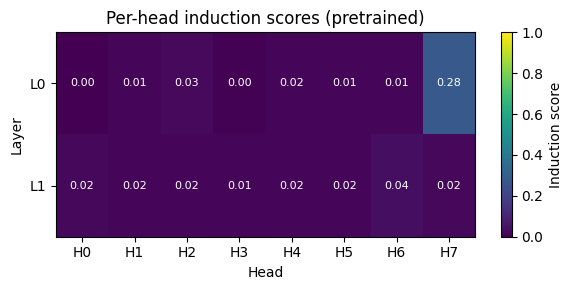

Figure 3 saved to /content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning/paper/figures


In [6]:
# Use absolute paths for saving figures
figures_dir = Path('/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning/paper/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

fig = plot_induction_score_heatmap(means.cpu().numpy(),
    title='Per-head induction scores (pretrained)',
    save_path=figures_dir / 'fig3_induction_scores_baseline')

plt.show()
print(f'Figure 3 saved to {figures_dir}')